# Proyecto Final - Caso Principal: Telecomunicaciones

## Objetivo del proyecto

Identificar operadores ineficaces en una empresa de telecomunicaciones mediante el análisis de datos históricos de llamadas.

Este análisis busca definir criterios objetivos para detectar operadores con bajo desempeño y generar recomendaciones que ayuden a mejorar la eficiencia operativa y la experiencia del cl
iente.


## 1. Entendimiento del problema de negocio

El objetivo de este proyecto es identificar operadores ineficaces en una empresa de telecomunicaciones, utilizando datos históricos de llamadas.

Un operador ineficaz puede impactar negativamente en la experiencia del cliente, aumentar los costos operativos y reducir la eficiencia general del servicio. Identificar estos operadores permitre a la empresa tomar decisiones informadas, como capacitaciones específicas, redistribución de carga de trabajo o ajustes en los procesos.

Antes de analizar los datos, es necesario definir criterios que nos ayuden a evaluar el desempeño de los operadores.


## Hipótesis iniciales

Planteamos las siguientes hipótesis que serán evaluadas con datos:

1. Algunos operadores presentan un desempeño inferior al promedio en métricas clave como duración de llamadas y número de llamadas atendidas.
2. Operadores con mayor número de llamadas repetidas podrían estar resolviendo problemas de manera menos efectiva.
3. Existen operadores cuyo desempeño se mantiene consistentemente bajo en comparación con otros, lo que permite clasificarlos como ineficaces.


## 2. Carga y exploración inicial de los datos (EDA)

En esta sección se cargan los datos y se realiza una exploración inicial
para comprender la estructura del dataset, los tipos de variables y
la calidad general de la información antes de continuar con el análisis.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('telecom_dataset_new (1).csv')
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


El dataset contiene 53,902 registros y 9 variables.
La mayoría de las columnas no presenta valores ausentes.

Las columnas operator_id e internal contienen valores faltantes, lo cual es consistente con llamadas posiblemente perdidas o no asignadas.
Estos valores serán analizados más adelante como posibles indicadores de ineficiencia operativa.

In [8]:
df['is_missed_call'].value_counts()

is_missed_call
False    30334
True     23568
Name: count, dtype: int64

El 44% de las llamadas fueron perdidas
Esto representa un porcentaje altísimo, casi la mitad no se atienden.

In [10]:
missed_by_direction = df.groupby(['direction', 'is_missed_call'])['calls_count'].sum()
print(missed_by_direction)


direction  is_missed_call
in         False             103399
           True              113464
out        False             371051
           True              298841
Name: calls_count, dtype: int64


In [11]:
missed_rate = (
    df.groupby('direction')['is_missed_call']
      .value_counts(normalize=True)
)

print(missed_rate)


direction  is_missed_call
in         False             0.606868
           True              0.393132
out        False             0.532381
           True              0.467619
Name: proportion, dtype: float64


### Hallazgos del EDA

A partir de la exploración inicial se observó que el dataset contiene información suficiente para evaluar el desempeño de los operadores. También se identificaron valores ausentes en algunas columnas, los cuales parecen estar asociados a llamadas no asignadas o perdidas y serán considerados durante el análisis.

Además, se detectó una proporción importante de llamadas perdidas, lo que refuerza la necesidad de identificar operadores con bajo desempeño.

## 3. Definición de métricas de desempeño

En esta sección se construye un resumen del desempeño de cada operador mediante métricas agregadas como el número de llamadas, la proporción de llamadas perdidas y la duración promedio de las llamadas. Estas métricas servirán como base para identificar operadores potencialmente ineficaces.

### Criterio metodológico

Para evaluar la ineficacia de los operadores, se dará prioridad al análisis de llamadas entrantes. Esto se debe a que una llamada entrante perdida puede reflejar falta de atención o disponibilidad del operador, mientras que una llamada saliente perdida puede depender de que el cliente no conteste.

Por esta razón, la proporción de llamadas perdidas se calculará utilizando únicamente llamadas entrantes.

In [15]:
incoming_calls = df[df['direction'] == 'in'].copy()

incoming_calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
17,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,880028.0,False,1,407,411


In [16]:

operator_stats = (
    df
    .dropna(subset=['operator_id'])
    .groupby('operator_id')
    .agg({
        'calls_count': 'sum',
        'is_missed_call': 'mean',
        'call_duration': 'mean',
        'total_call_duration': 'mean'
    })
)
print(operator_stats.head())



             calls_count  is_missed_call  call_duration  total_call_duration
operator_id                                                                 
879896.0            1131        0.390625     650.476562           761.148438
879898.0            7974        0.398406    1111.067729          1561.155378
880020.0              54        0.318182     104.090909           119.272727
880022.0             219        0.434211     240.842105           298.407895
880026.0            2439        0.474747     856.939394           978.111111


Consideraremos que un operador es ineficaz si:

* Tiene una proporción alta de llamadas perdidas

* Presenta tiempos de espera elevados

* O se presetnan ambas situaciones

In [18]:
operator_stats['total_call_duration'].quantile(0.75)

832.3510922520824

In [19]:
operator_stats['is_missed_call'].quantile(0.75)


0.46153846153846156

## 4. Identificación de operadores ineficaces

Una vez definidas las métricas de desempeño, se establecen umbrales utilizando cuantiles para clasificar objetivamente a los operadores con un desempeño inferior al esperado.

In [21]:
missed_threshold = operator_stats['is_missed_call'].quantile(0.75)
duration_threshold = operator_stats['total_call_duration'].quantile(0.75)

operator_stats['ineffective'] = (
    (operator_stats['is_missed_call'] > missed_threshold) |
    (operator_stats['total_call_duration'] > duration_threshold)
)

operator_stats.head()


,calls_count,is_missed_call,call_duration,total_call_duration,ineffective
operator_id,,,,,
879896.0,1131,0.390625,650.476562,761.148438,False
879898.0,7974,0.398406,1111.067729,1561.155378,True
880020.0,54,0.318182,104.090909,119.272727,False
880022.0,219,0.434211,240.842105,298.407895,False
880026.0,2439,0.474747,856.939394,978.111111,True


In [22]:
operator_stats['ineffective'].value_counts()


ineffective
False    673
True     419
Name: count, dtype: int64

In [23]:
operator_stats['ineffective'].value_counts(normalize=True) * 100


ineffective
False    61.630037
True     38.369963
Name: proportion, dtype: float64

In [24]:
ineffective_ops = operator_stats[operator_stats['ineffective']]
ineffective_ops.head()


,calls_count,is_missed_call,call_duration,total_call_duration,ineffective
operator_id,,,,,
879898.0,7974,0.398406,1111.067729,1561.155378,True
880026.0,2439,0.474747,856.939394,978.111111,True
880028.0,2906,0.402655,746.265487,956.858407,True
880240.0,49,0.571429,275.928571,316.857143,True
881278.0,20,0.875000,58.125000,67.875000,True


In [25]:
ineffective_ops.describe()


,calls_count,is_missed_call,call_duration,total_call_duration
count,419.000000,419.000000,419.000000,419.000000
mean,1573.844869,0.504024,1341.092127,1821.330557
std,5004.011152,0.201989,1703.561865,2333.327640
min,1.000000,0.000000,0.000000,0.000000
25%,29.000000,0.400000,148.016667,204.264479
50%,692.000000,0.500000,889.764706,1178.107143
75%,1781.000000,0.546921,1677.604167,2288.560345
max,66049.000000,1.000000,14620.545455,19436.786834


In [26]:
operator_stats.groupby('ineffective').mean()


,calls_count,is_missed_call,call_duration,total_call_duration
ineffective,,,,
False,168.793462,0.196188,216.825694,267.416089
True,1573.844869,0.504024,1341.092127,1821.330557


En la tabla se puede observar que los operadores 'ineficaces' atienen mas llamadas que los operadores 'eficaces'. Esto puede significar una mala asignación/distribución de llamadas por parte del sistema, operadores saturados o falta de rotación de personal.

En la columna de 'is_missed_call', se puede destacar que los operadores ineficaces pierden 1 de cada 2 llamadas, mientras que los operadores eficaces pierden solo 1 de cada 5
Los operadores clasificados como ineficaces presentan una tasa de llamadas perdidas significativamente mayor (50% aproximadamente) en comparación con los operadores eficaces (20% paroximadamente). Además, manejan un volumen de llamadas considerablemente más alto y presentan duraciones promedio de llamadas y tiempos de espera mucho mayores, lo que sugiere sobrecarga operativa y menor eficiencia en la resolución de llamadas

## 5. Visualización de resultados

Los siguientes gráficos permiten comparar el comportamiento de los operadores clasificados como eficaces e ineficaces para identificar diferencias relevantes en sus métricas de desempeño.

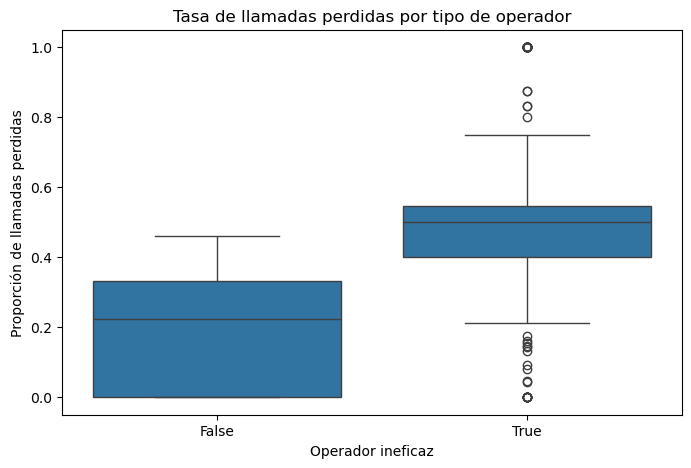

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='ineffective',
    y='is_missed_call',
    data=operator_stats
)

plt.title('Tasa de llamadas perdidas por tipo de operador')
plt.xlabel('Operador ineficaz')
plt.ylabel('Proporción de llamadas perdidas')
plt.show()


El diagrama de cajas y bigotes muestra una diferencia entre operadores eficaces e ineficaces. Los operadores clasificados como ineficaces presentan una mediana significativamente mayor en la proporción de llamadas perdidas. Esto respalda el criterio utilizado para identificar ineficacia y sugiere que estos operadores impactan negativamente la experiencia del cliente.
También se pueden observar puntos semi-aislados (outliers), que pierden más del 50% de sus llamadas, incluso casi el 100%.
Estos operadores son críticos y podrían ser:

Nuevos
Mal capacitados
Asignados a casos difíciles
Operadosres que no están haciendo su trabajo

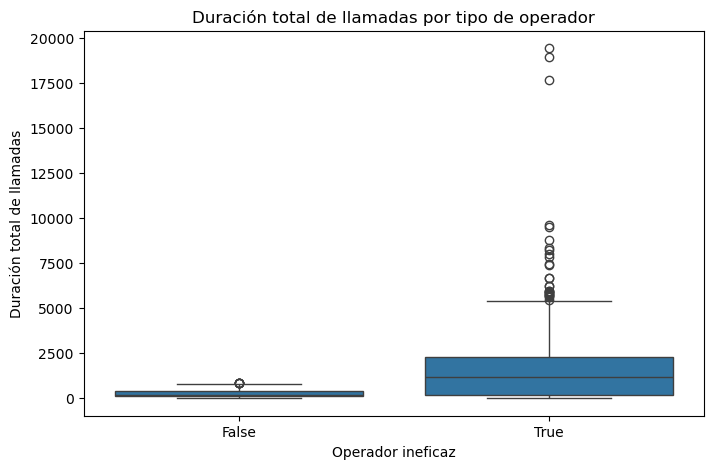

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='ineffective',
    y='total_call_duration',
    data=operator_stats
)

plt.title('Duración total de llamadas por tipo de operador')
plt.xlabel('Operador ineficaz')
plt.ylabel('Duración total de llamadas')
plt.show()


En este diagrama de cajas y bigotes, se puede observar que los operadores eficaces tienen llamadas más cortas y muchos menos outliers. Po otro lado, en la caja de operadores clasificados cono ineficaces, las llamadas parecen ser más largas y hay un número considerablemente más alto de outliers, lo cual puede significar altos tiempos de espera sin resolver, mayor frustración del cliente y más llamadas perdidas.

In [36]:
mean_stats = operator_stats.groupby('ineffective')[
    ['is_missed_call', 'total_call_duration']
].mean()

mean_stats

,is_missed_call,total_call_duration
ineffective,,
False,0.196188,267.416089
True,0.504024,1821.330557


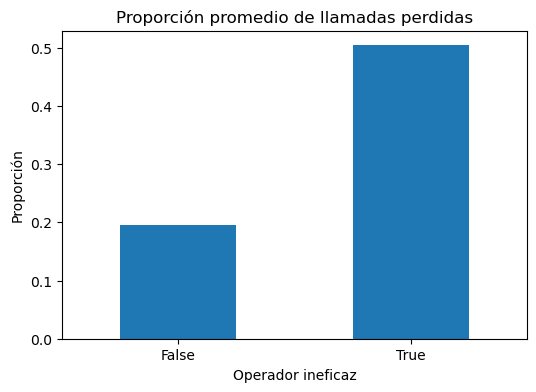

In [38]:
mean_stats['is_missed_call'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Proporción promedio de llamadas perdidas')
plt.xlabel('Operador ineficaz')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.show()

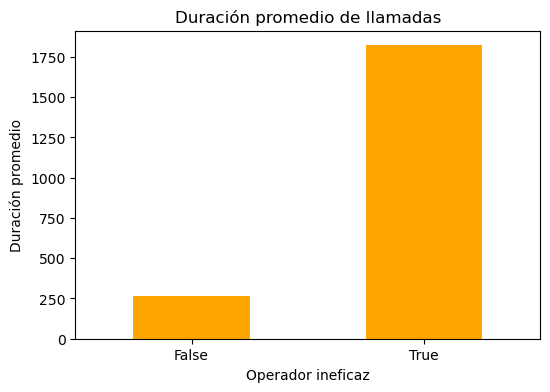

In [40]:
mean_stats['total_call_duration'].plot(
    kind='bar',
    figsize=(6,4),
    color='orange'
)

plt.title('Duración promedio de llamadas')
plt.xlabel('Operador ineficaz')
plt.ylabel('Duración promedio')
plt.xticks(rotation=0)
plt.show()